In [15]:
import wbgapi as wb
import pandas as pd
import numpy as np

pop_gdp_data = wb.data.DataFrame(["SP.POP.GROW", "NY.GDP.MKTP.KD.ZG", "FP.CPI.TOTL.ZG"], 'JPN', mrv=50)
pop_data = wb.data.DataFrame(["SP.POP.GROW"], "JPN")
pop_gdp_data = pop_gdp_data.T
pop_gdp_data.columns = ["Inflation Rate", "GDP Growth", "Population Growth"]
pop_gdp_data["Next Year GDP Growth"] = pop_gdp_data["GDP Growth"].shift(-1)
pop_gdp_data.index = pop_gdp_data.index.str.replace("YR", "", regex=False)
pop_gdp_data_copy = pop_gdp_data.copy()
pop_gdp_data.dropna(inplace=True)
pop_gdp_data

,Inflation Rate,GDP Growth,Population Growth,Next Year GDP Growth
1975,11.731266,3.091576,1.272708,3.974984
1976,9.374036,3.974984,1.071560,4.390338
1977,8.161827,4.390338,0.968033,5.271942
1978,4.209566,5.271942,0.910031,5.484042
1979,3.701851,5.484042,0.846615,2.817591
1980,7.778582,2.817591,0.788153,4.260624
1981,4.912163,4.260624,0.728461,3.279743
1982,2.741041,3.279743,0.693656,3.630199
1983,1.899720,3.630199,0.695583,4.410880
1984,2.261614,4.410880,0.648317,5.159808


In [8]:
import statsmodels.api as sm

X = pop_gdp_data[["Population Growth"]]
y = pop_gdp_data["Next Year GDP Growth"]

X_with_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_with_const).fit()
print(model_sm.summary())

                             OLS Regression Results                             
Dep. Variable:     Next Year GDP Growth   R-squared:                       0.325
Model:                              OLS   Adj. R-squared:                  0.311
Method:                   Least Squares   F-statistic:                     22.67
Date:                  Sun, 31 Aug 2025   Prob (F-statistic):           1.88e-05
Time:                          23:22:17   Log-Likelihood:                -102.30
No. Observations:                    49   AIC:                             208.6
Df Residuals:                        47   BIC:                             212.4
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             

In [16]:
X = pop_gdp_data[["Population Growth"]]
y = pop_gdp_data["GDP Growth"]

X_with_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_with_const).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP Growth   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     21.80
Date:                Sun, 31 Aug 2025   Prob (F-statistic):           2.55e-05
Time:                        23:24:09   Log-Likelihood:                -102.40
No. Observations:                  49   AIC:                             208.8
Df Residuals:                      47   BIC:                             212.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.1707      0.33

In [10]:
japan_gdp_growth = (wb.data.DataFrame("NY.GDP.MKTP.KD.ZG", 'JPN', mrv=100)).T
japan_gdp_growth.columns = ["GDP Growth"]
japan_gdp_growth.index = japan_gdp_growth.index.str.replace("YR", "", regex=False)
japan_gdp_growth.index = japan_gdp_growth.index.astype(int)
japan_gdp_growth

,GDP Growth
1961,12.043536
1962,8.908973
1963,8.473642
1964,11.676708
1965,5.819708
...,...
2020,-4.168765
2021,2.696574
2022,0.941999
2023,1.475035


In [11]:
japan_pop_growth= (wb.data.DataFrame("SP.POP.GROW", 'JPN', mrv=100)).T
japan_pop_growth.columns = ["Population Growth"]
japan_pop_growth.index = japan_pop_growth.index.str.replace("YR", "", regex=False)
japan_pop_growth.index = japan_pop_growth.index.astype(int)
japan_pop_growth

,Population Growth
1961,0.896034
1962,0.929166
1963,1.013460
1964,1.040450
1965,1.076708
...,...
2020,-0.294195
2021,-0.459952
2022,-0.443852
2023,-0.487371


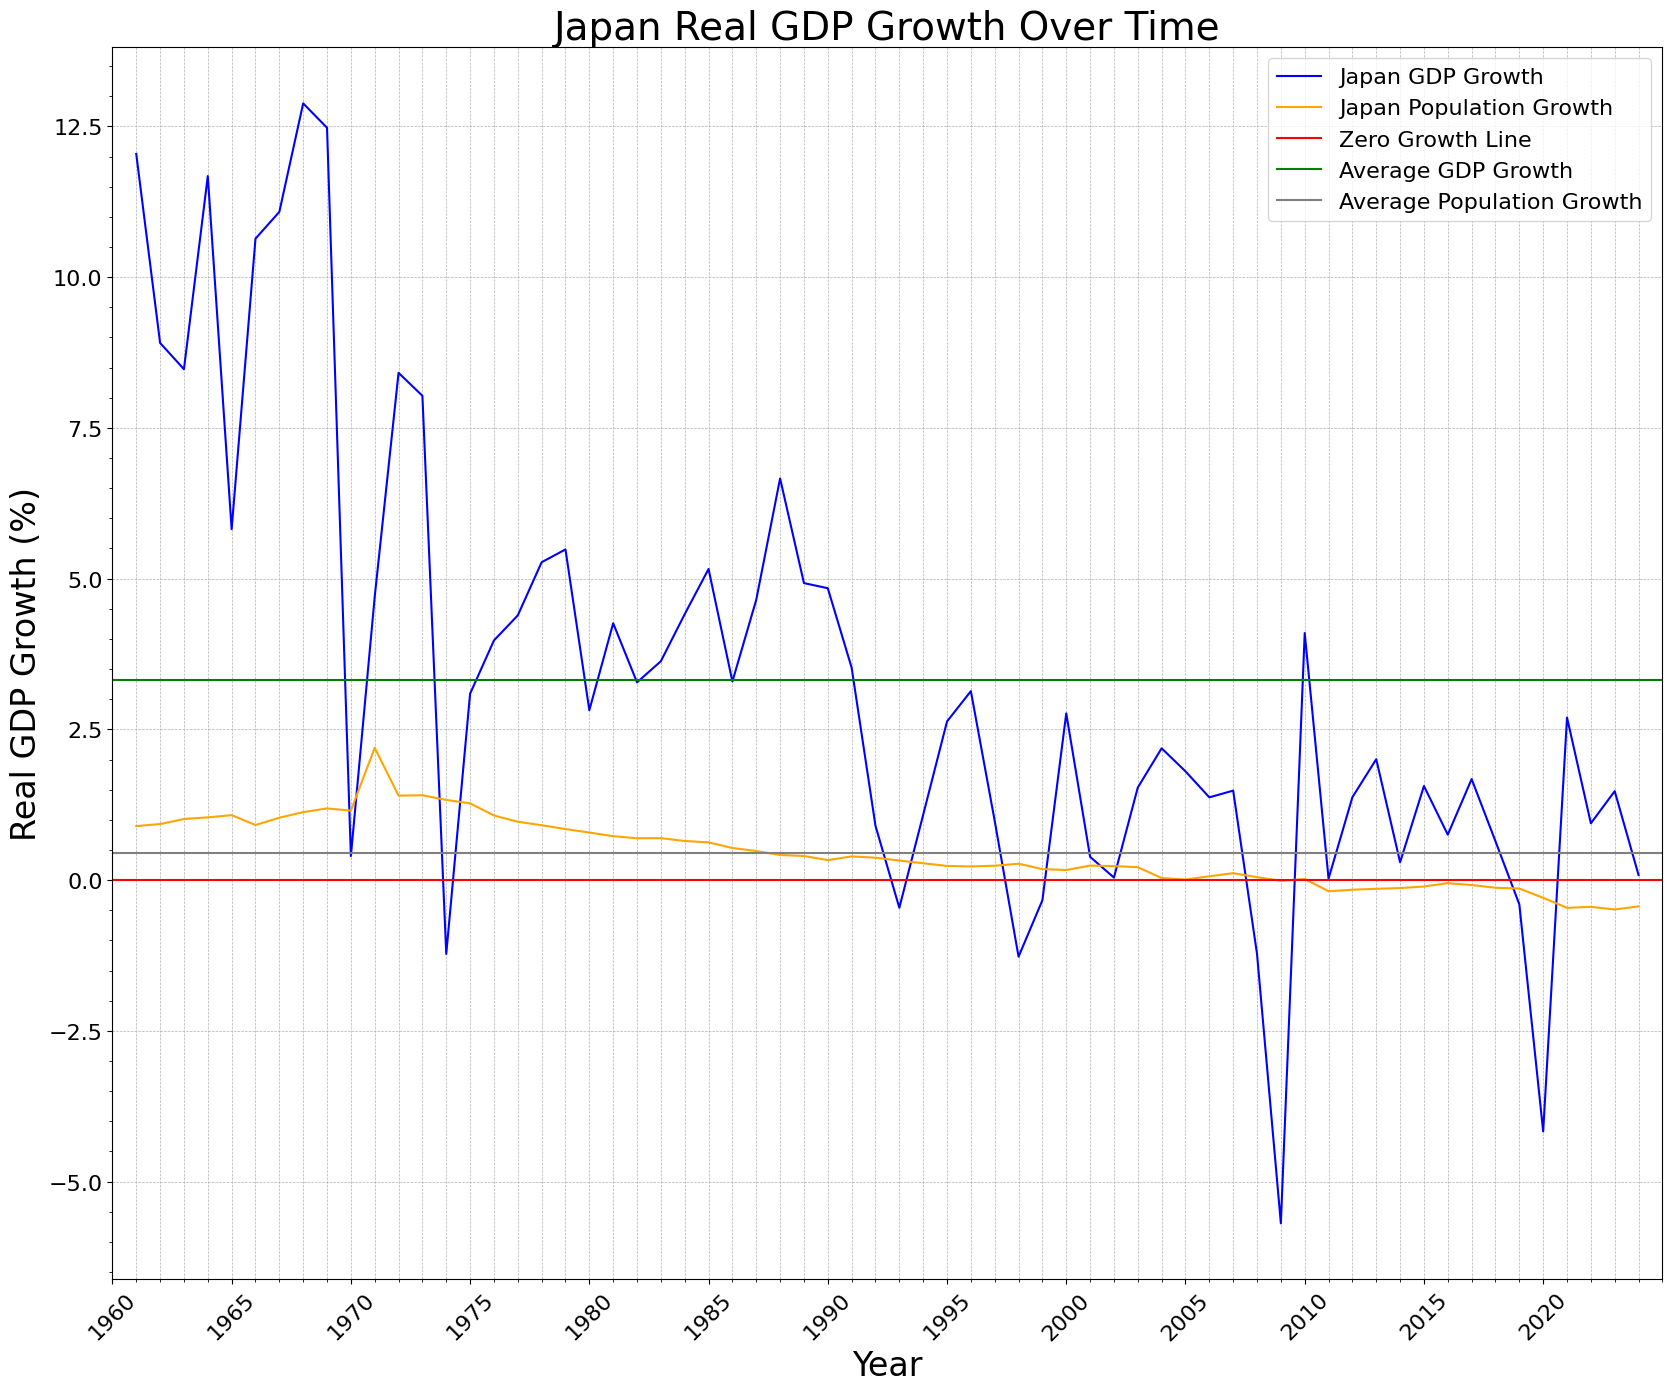

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
plt.plot(japan_gdp_growth["GDP Growth"], label="Japan GDP Growth", color="blue")
plt.plot(japan_pop_growth["Population Growth"], label="Japan Population Growth", color="orange")

plt.axhline(0, color="red", label="Zero Growth Line")
plt.axhline(japan_gdp_growth["GDP Growth"].mean(), color="green", label="Average GDP Growth")
plt.axhline(japan_pop_growth["Population Growth"].mean(), color="gray", label="Average Population Growth")

x_ticks = np.arange(1960, 2025, 5)

plt.xlabel("Year", fontsize=24)
plt.ylabel("Real GDP Growth (%)", fontsize=24)
plt.xlim(1960, 2025)
plt.xticks(x_ticks, rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.minorticks_on()
plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

plt.title("Japan Real GDP Growth Over Time", fontsize=28)
plt.legend(fontsize=16)
plt.show()

In [14]:
print(np.corrcoef(japan_gdp_growth["GDP Growth"], japan_pop_growth["Population Growth"])[0][1])

0.6189130510185906
